In [1]:
# This is only an example of how to retrieve things

from tudatpy.data.mpc import BatchMPC
from tudatpy.interface import spice
from tudatpy.dynamics import environment, environment_setup
from tudatpy.dynamics import propagation_setup, parameters_setup, simulator
from tudatpy.estimation import observable_models_setup, observable_models, observations_setup, observations, estimation_analysis


from tudatpy.data.horizons import HorizonsQuery

from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
from astroquery.mpc import MPC


# Load spice kernels
spice.load_standard_kernels()

In [2]:
asteroid_MPC_codes = [1566, 66146, 66391, 437844, 137924, 138127, 480883, 468468, 364136]

asteroid_designations = [
    "1566 Icarus",
    "1998 TU3",
    "1999 KW4",
    "1999 MN",
    "2000 BD19",
    "2000 EE14",
    "2001 YE4",
    "2004 KH17",
    "2006 CJ"
]

batch1 = BatchMPC()

batch1.get_observations(asteroid_MPC_codes)

batch1.summary()
print(batch1.observatories_table(only_in_batch=True, only_space_telescopes=False, include_positions=False))
print()
print("Space Telescopes:")
print(batch1.observatories_table(only_in_batch=True, only_space_telescopes=True, include_positions=False))

/home/emmabob/miniconda3/envs/tudat-space/lib/python3.10/site-packages/tudatpy/data/mpc/mpc.py:866: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['1566' '1566' '1566' ... '1566' '1566' '1566']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  obs.loc[:, "number"] = obs.number.astype(str)
/home/emmabob/miniconda3/envs/tudat-space/lib/python3.10/site-packages/tudatpy/data/mpc/mpc.py:866: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['66146' '66146' '66146' ... '66146' '66146' '66146']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  obs.loc[:, "number"] = obs.number.astype(str)
/home/emmabob/miniconda3/envs/tudat-space/lib/python3.10/site-packages/tudatpy/data/mpc/mpc.py:866: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a fut


   Batch Summary:
1. Batch includes 9 minor planets:
   ['1566', '66146', '66391', 'h7844', 'D7924', 'D8127', 'm0883', 'k8468', 'a4136']
2. Batch includes 12204 observations, including 776 observations from space telescopes
3. The observations range from 1949-06-27 05:44:00.096013 to 2026-04-20 11:30:00.633618
   In seconds TDB since J2000: -1594102527.7197719 to 829956669.8192015
   In Julian Days: 2433094.73889 to 2461150.979174
4. The batch contains observations from 323 observatories, including 2 space telescopes

     Code                               Name  count
6     006       Fabra Observatory, Barcelona   80.0
12    012                              Uccle   12.0
20    020                               Nice    2.0
24    024              Heidelberg-Konigstuhl    1.0
26    026                   Berne-Zimmerwald   20.0
...   ...                                ...    ...
2646  Z43                           Landehen   19.0
2655  Z52  The Studios Observatory, Grantham    8.0
2683  Z

In [4]:
print(batch1.table.columns)

Index(['number', 'desig', 'discovery', 'note1', 'note2', 'epoch', 'RA', 'DEC',
       'mag', 'band', 'catalog', 'observatory', 'epochJ2000secondsTDB',
       'epochUTC'],
      dtype='object')


In [6]:
obs_by_TESS = batch1.table.query("observatory == 'C57'").loc[:, ["number", "epochJ2000secondsTDB", "RA", "DEC"]].iloc[[0, -1]]
obs_by_WISE = batch1.table.query("observatory == 'C51'").loc[:, ["number", "epochJ2000secondsTDB", "RA", "DEC"]].iloc[[0, -1]]

print("Initial and Final Observations by TESS")
print(obs_by_TESS)
print()
print("Initial and Final Observations by WISE")
print(obs_by_WISE)

Initial and Final Observations by TESS
     number  epochJ2000secondsTDB        RA       DEC
1318   1566          6.494571e+08  5.683070 -0.871555
527   a4136          6.677925e+08  2.314114 -0.261199

Initial and Final Observations by WISE
    number  epochJ2000secondsTDB        RA       DEC
919   1566          3.375784e+08  4.594339 -1.148961
392  a4136          5.420847e+08  1.503626  0.235668


In [8]:
# To check that all observations exist in the batch
# If it fails, then they aren't
# print(batch1.table["observatory"].unique())

In [10]:
# Using filters to take out very old data (1980s)

observatories_to_exclude = ["000"] # chose Greenwich (000) as an example to completely exclude its data

# Epoch start = 2018-01-01 00:00:00 UTC
# No observations before are allowed in

# epoch_end = 746013855.0
# No observations after 746013855 seconds after J2000 (around 2023-08)

# Additionally, I want to perserve the original:
batch_before_filter = batch1.copy()

print(f"Size before filter: {batch1.size}")
batch1.filter(observatories_exclude=observatories_to_exclude, epoch_start=datetime(2018, 1, 1), epoch_end=746013855.0)
print(f"Size after filter: {batch1.size}")

batch1.summary()

Size before filter: 3810
Size after filter: 3810

   Batch Summary:
1. Batch includes 9 minor planets:
   ['1566', '66146', '66391', 'h7844', 'D7924', 'D8127', 'm0883', 'k8468', 'a4136']
2. Batch includes 3810 observations, including 557 observations from space telescopes
3. The observations range from 2018-01-08 11:43:42.816002 to 2023-08-06 06:42:31.478416
   In seconds TDB since J2000: 568683892.0001373 to 744576220.6615851
   In Julian Days: 2458126.98869 to 2460162.779531
4. The batch contains observations from 99 observatories, including 2 space telescopes



In [11]:
# Create the environment

bodies_to_create = ["Sun", "Earth"]

# Create default body settings
global_frame_origin = "SSB"
global_frame_orientation = "J2000"
body_settings = environment_setup.get_default_body_settings(
    bodies_to_create, global_frame_origin, global_frame_orientation)

# Create system of bodies
bodies = environment_setup.create_system_of_bodies(body_settings)


In [12]:
# Retrieve the Observation Collection

# Step 1:
# Define the Observation Collection
observation_collection = batch1.to_tudat(bodies, included_satellites=None, apply_star_catalog_debias = False)

# Step 2:
# Retrieve names and dates from the batch
epoch_start = batch1.epoch_start # in seconds since J2000 TDB (Tudat default)
epoch_end = batch1.epoch_end
object_names = batch1.MPC_objects

# Step 3:
# Retrieve the links from the ObservationCollection we got from to_tudat() and create settings for these links.
# Here the links are just set to default
observation_settings_list = list()

link_list = list(
    observation_collection.get_link_definitions_for_observables(
        observable_type=observable_models_setup.model_settings.angular_position_type
    )
)

for link in link_list:
    # add optional bias settings
    observation_settings_list.append(
        observable_models_setup.model_settings.angular_position(link, bias_settings=None)
    )

/home/emmabob/miniconda3/envs/tudat-space/lib/python3.10/site-packages/tudatpy/data/mpc/mpc.py:866: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['66146' '66146' '66146' ... '66146' '66146' '66146']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  obs.loc[:, "number"] = obs.number.astype(str)


Maximum difference between Interpolated Horizons data and MPC observations:
Right Ascension: 0.0013422736 rad
Declination: 0.0003032941 rad


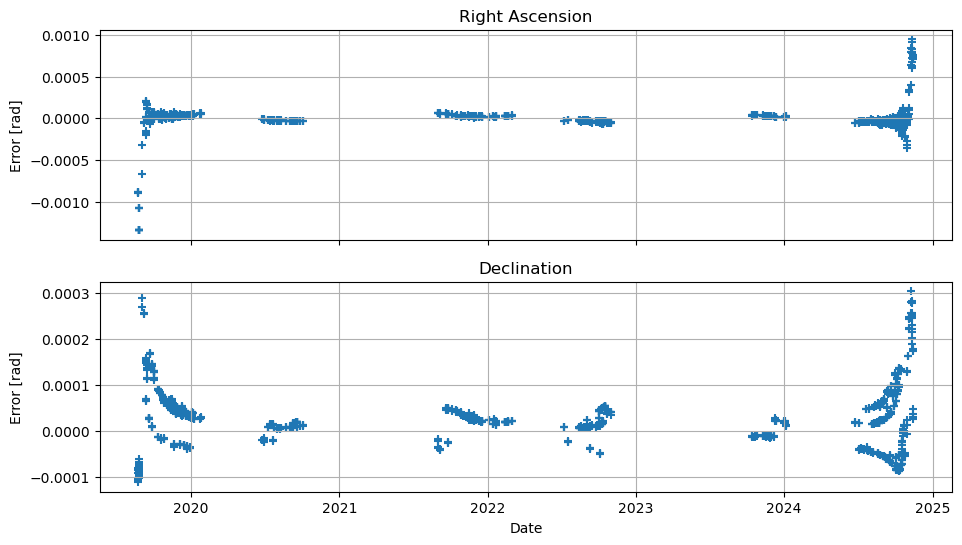

In [14]:
# Let's simplify by using only 1998 TU3 and removing observations from space telescopes
target = "66146"
target_horizons = target + ";" # ; specifies minor bodies

batch_TU3_test = BatchMPC()
batch_TU3_test.get_observations([target])
batch_TU3_test.filter(
    epoch_start=datetime(2018, 1, 1),
    observatories_exclude=["C51", "C57"],
)

# Retrieve MPC observation times, RA and DEC
batch_times = batch_TU3_test.table.epochJ2000secondsTDB.to_list()
batch_times_utc = batch_TU3_test.table.epochUTC.to_list()
batch_RA = batch_TU3_test.table.RA
batch_DEC = batch_TU3_test.table.DEC

# Create Horizons query, see Horizons Documentation for more info.
hypatia_horizons_query = HorizonsQuery(
    query_id=target_horizons,
    location="500@399",  # geocenter @ Earth
    epoch_list=batch_times,
    extended_query=True,
)

# retrieve JPL observations
jpl_observations = hypatia_horizons_query.interpolated_observations()
jpl_RA = jpl_observations[:, 1]
jpl_DEC = jpl_observations[:, 2]

max_diff_RA = np.abs(jpl_RA - batch_RA).max()
max_diff_DEC = np.abs(jpl_DEC - batch_DEC).max()
print("Maximum difference between Interpolated Horizons data and MPC observations:")
print(f"Right Ascension: {np.round(max_diff_RA, 10)} rad")
print(f"Declination: {np.round(max_diff_DEC, 10)} rad")

# create plot
fig, (ax_ra, ax_dec) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

ax_ra.scatter(batch_times_utc, (jpl_RA - batch_RA), marker="+")
ax_dec.scatter(batch_times_utc, (jpl_DEC - batch_DEC), marker="+")

ax_ra.set_ylabel("Error [rad]")
ax_dec.set_ylabel("Error [rad]")
ax_dec.set_xlabel("Date")

ax_ra.grid()
ax_dec.grid()

ax_ra.set_title("Right Ascension")
ax_dec.set_title("Declination")

plt.show()

In [16]:
# Note that we are using the add_empty_settings() method instead of add_empty_body().
# This allows us to add ephemeris settings,
# which tudat uses to create an ephemeris which is consistent with the rest of the environment.
TESS_code = "-95"
body_settings.add_empty_settings("TESS")

# Set up the space telescope's dynamics, TESS orbits earth
# the spice kernel can be retrieved from: https://archive.stsci.edu/missions/tess/models/
spice.load_kernel(r"tess_20_year_long_predictive.bsp")
body_settings.get("TESS").ephemeris_settings =  environment_setup.ephemeris.direct_spice(
     "Earth", global_frame_orientation, TESS_code)

# NOTE this is incorrect, here we are trying to set the ephemeris directly:
# Setting the ephemeris settings allows tudat to complete the relevant setup for the body.
# bodies.create_empty_body("TESS")
# bodies.get("TESS").ephemeris = environment_setup.ephemeris.direct_spice(
#      global_frame_origin, global_frame_orientation, TESS_code)

# Create system of bodies
bodies = environment_setup.create_system_of_bodies(body_settings)
# create dictionary to link names. MPCcode:NameInTudat
sats_dict = {"C57":"TESS"}

observation_collection = batch1.to_tudat(bodies, included_satellites=sats_dict, apply_star_catalog_debias = False)

In [25]:
mpc_code_hypatia = 238
data = MPC.get_observations(mpc_code_hypatia)

# ...
# Any additional filtering steps
# ...

batch2 = BatchMPC()
batch2.from_astropy(data)

# alternative if pandas is preferred:
# data_pandas = data.to_pandas()
# batch2.from_astropy(data_pandas)

batch2.summary()


   Batch Summary:
1. Batch includes 1 minor planets:
   ['238']
2. Batch includes 5222 observations, including 279 observations from space telescopes
3. The observations range from 1892-03-18 22:48:06.047982 to 2026-01-12 16:03:56.246382
   In seconds TDB since J2000: -3401442681.766395 to 821505905.4306374
   In Julian Days: 2412176.45007 to 2461053.169401
4. The batch contains observations from 111 observatories, including 2 space telescopes



In [26]:
batch3 = batch2 + batch1
batch3.summary()


   Batch Summary:
1. Batch includes 10 minor planets:
   ['238', 'D7924', '66391', '1566', 'D8127', 'k8468', '66146', 'h7844', 'a4136', 'm0883']
2. Batch includes 9032 observations, including 836 observations from space telescopes
3. The observations range from 1892-03-18 22:48:06.047982 to 2026-01-12 16:03:56.246382
   In seconds TDB since J2000: -3401442681.766395 to 821505905.4306374
   In Julian Days: 2412176.45007 to 2461053.169401
4. The batch contains observations from 184 observatories, including 3 space telescopes



In [27]:
# Copying existing batches:
import copy
batch1_copy = copy.copy(batch1)
# simpler equivalent:
batch1_copy = batch1.copy()

# normal in-place/destructive filter
batch1_copy.filter(epoch_start=datetime(2023, 1, 1)) # returns None
# non-destructive filter:
batch1_copy2 = batch1.filter(epoch_start=datetime(2023, 1, 1), in_place=False) # returns filtered copy

batch1_copy.summary()
batch1_copy2.summary()


   Batch Summary:
1. Batch includes 4 minor planets:
   ['1566', '66391', 'D7924', 'D8127']
2. Batch includes 167 observations, including 7 observations from space telescopes
3. The observations range from 2023-01-13 07:02:58.876787 to 2023-08-06 06:42:31.478416
   In seconds TDB since J2000: 726865448.0610027 to 744576220.6615851
   In Julian Days: 2459957.793737 to 2460162.779531
4. The batch contains observations from 12 observatories, including 1 space telescopes


   Batch Summary:
1. Batch includes 4 minor planets:
   ['1566', '66391', 'D7924', 'D8127']
2. Batch includes 167 observations, including 7 observations from space telescopes
3. The observations range from 2023-01-13 07:02:58.876787 to 2023-08-06 06:42:31.478416
   In seconds TDB since J2000: 726865448.0610027 to 744576220.6615851
   In Julian Days: 2459957.793737 to 2460162.779531
4. The batch contains observations from 12 observatories, including 1 space telescopes



In [29]:
print(329 in batch1.get_object_ids())

AttributeError: 'BatchMPC' object has no attribute 'get_object_ids'

In [30]:
objects = batch1.get_object_ids()
print(objects[:10])

AttributeError: 'BatchMPC' object has no attribute 'get_object_ids'

In [31]:
valid_objects = [
    obj for obj in batch1.get_object_ids()
    if len(batch1.get_observations_of_object(obj)) > 0
]

fig = batch1.plot_observations_sky(objects=valid_objects[:3])
plt.show()

AttributeError: 'BatchMPC' object has no attribute 'get_object_ids'

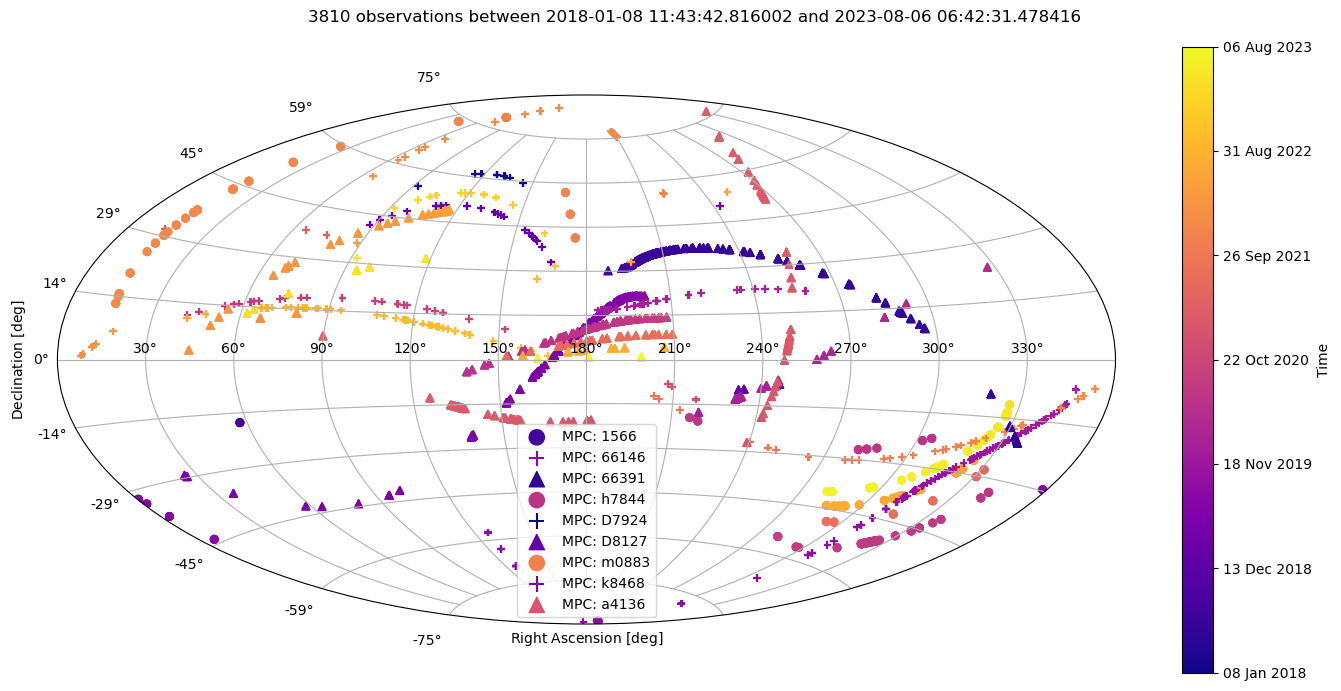

In [32]:
fig = batch1.plot_observations_sky(projection="aitoff")
plt.show()

ValueError: cannot convert float NaN to integer

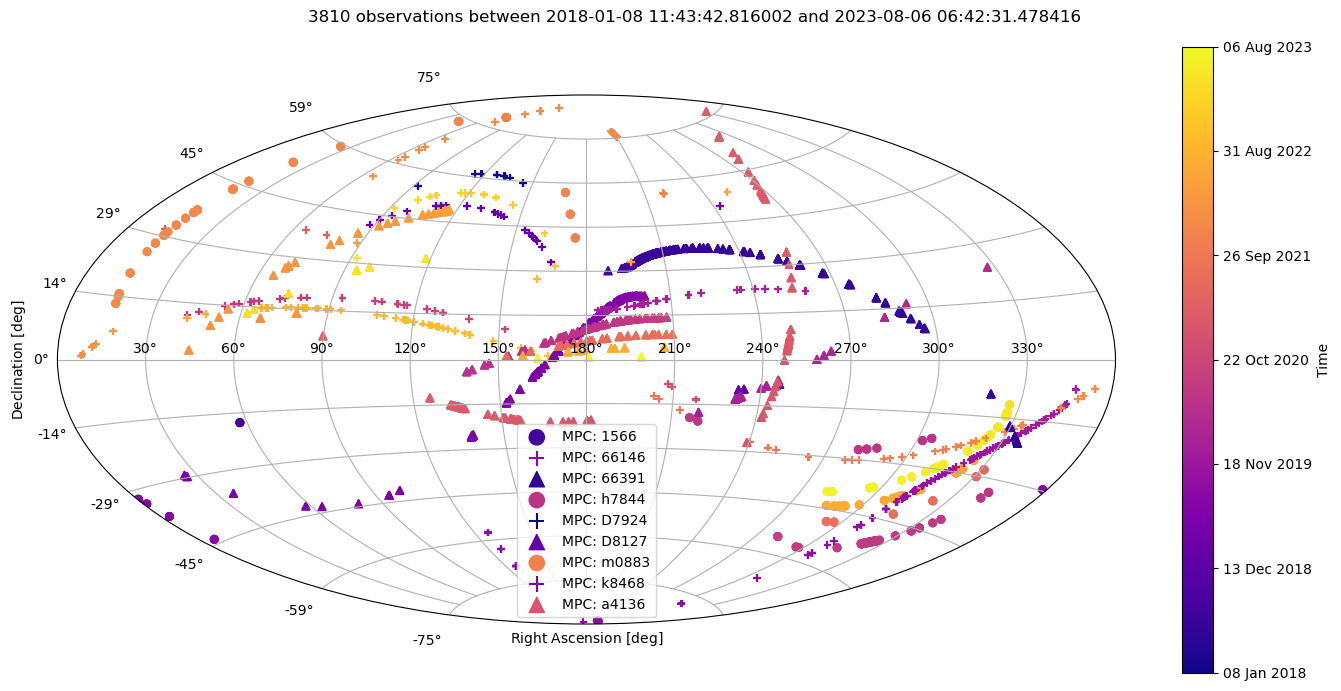

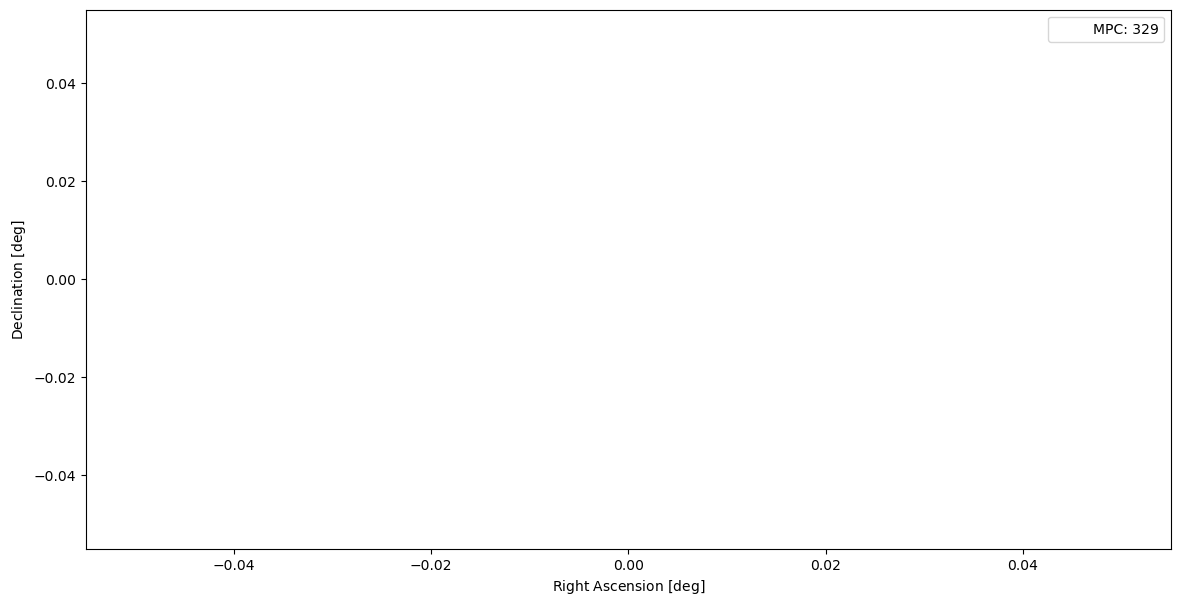

In [28]:
# Try some of the other projections: 'hammer', 'mollweide' and 'lambert'
fig = batch1.plot_observations_sky(projection="aitoff")
# specific objects can be selected for large batches:
fig = batch1.plot_observations_sky(projection=None, objects=[329])

plt.show()